<a href="https://colab.research.google.com/github/DymaStar/DTA_2026/blob/main/ML/DS_Classification__DTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Щоб результати були однаковими щоразу (відтворюваність)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Бібліотеки готові ✅")

Бібліотеки готові ✅


In [2]:
m = 1200
tenure   = np.random.randint(1, 72, m)           # місяців з нами
monthly  = np.random.normal(70, 25, m).clip(15, 150)  # щомісячна оплата, $
support  = np.random.poisson(1.5, m)             # звернень у підтримку за рік
age      = np.random.randint(18, 75, m)          # вік клієнта

# Прихована логіка ризику відтоку (модель її не знає):
risk = (
    -0.05 * tenure        # довше з нами → менший ризик
    + 0.02 * monthly      # дорожчий тариф → трохи більший ризик
    + 0.45 * support      # багато звернень у підтримку → більший ризик
    - 0.01 * age          # старші клієнти трохи лояльніші
    + np.random.normal(0, 0.7, m)
)
prob = 1 / (1 + np.exp(-(risk - 0.5)))   # перетворюємо ризик на ймовірність 0..1
churn = (np.random.rand(m) < prob).astype(int)

df = pd.DataFrame({
    "tenure": tenure, "monthly": monthly.round(1),
    "support": support, "age": age, "churn": churn,
})

print("Частка клієнтів, що пішли:", f"{df['churn'].mean():.1%}")
df.head()

Частка клієнтів, що пішли: 39.3%


,tenure,monthly,support,age,churn
0,52,21.7,1,21,0
1,15,39.8,1,20,0
2,61,43.2,4,73,0
3,21,87.1,0,46,1
4,24,65.9,1,69,1


# Підготовка даних для прогнозування відтоку клієнтів

У цьому завданні модель буде прогнозувати:
- чи залишить клієнт сервіс (`churn`).

Для прогнозування використаємо такі ознаки:
- тривалість користування,
- щомісячний платіж,
- кількість звернень у підтримку,
- вік клієнта.

In [3]:
# Імпорт функції для поділу даних
from sklearn.model_selection import train_test_split

In [4]:
# Ознаки (features)
X = df[['tenure', 'monthly', 'support', 'age']]

# Цільова змінна (target)
y = df['churn']

## Пояснення ознак

### Features (X)
Ознаки, які використовуються для прогнозу:
- `tenure` — скільки часу клієнт користується сервісом,
- `monthly` — щомісячний платіж,
- `support` — кількість звернень у підтримку,
- `age` — вік клієнта.

### Target (y)
- `churn` — чи пішов клієнт із сервісу.

In [5]:
# RANDOM_STATE потрібен для однакових результатів при кожному запуску
RANDOM_STATE = 42

# Розділення даних на train та test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Перевірка розміру вибірок
print("Навчальна вибірка:", X_train.shape[0], "клієнтів")
print("Тестова вибірка:", X_test.shape[0], "клієнтів")

Навчальна вибірка: 960 клієнтів
Тестова вибірка: 240 клієнтів


## Висновок

Дані були успішно розділені:
- 80% використовується для навчання моделі,
- 20% — для тестування.

Навчальна вибірка містить 960 клієнтів, а тестова — 240 клієнтів.

Такий поділ дозволяє перевірити, наскільки добре модель прогнозує відтік клієнтів на нових даних.

# Створення моделі Decision Tree

Тепер створимо модель дерева рішень (`DecisionTreeClassifier`).

Decision Tree:
- аналізує ознаки,
- будує послідовність умов,
- та приймає рішення щодо класу.

У нашому випадку модель буде прогнозувати:
- чи піде клієнт із сервісу (`churn`).

In [6]:
# Імпорт моделі Decision Tree
from sklearn.tree import DecisionTreeClassifier

In [7]:
# Створення моделі
model_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=RANDOM_STATE
)

# Навчання моделі на train data
model_tree.fit(X_train, y_train)

# Прогноз для test data
y_pred = model_tree.predict(X_test)

## Пояснення параметрів

### max_depth=3
Обмежує максимальну глибину дерева.

Це допомагає:
- уникати перенавчання (overfitting),
- зробити модель простішою,
- покращити узагальнення на нових даних.

### random_state
Фіксує випадковість алгоритму для стабільних результатів при повторному запуску.

## Як працює дерево рішень

Decision Tree поступово ділить дані на групи за умовами.

Наприклад:
- якщо `tenure > 12`,
- і `support < 3`,
- тоді клієнт, ймовірно, залишиться.

Модель автоматично знаходить найкращі правила для поділу даних.

## Візуалізація дерева рішень

Після навчання моделі можемо побудувати дерево рішень та побачити:
- як модель приймає рішення,
- які ознаки є найважливішими,
- за якими умовами модель прогнозує churn.

Decision Tree працює як послідовність питань:
- якщо умова виконується → перехід в одну гілку,
- якщо ні → в іншу.

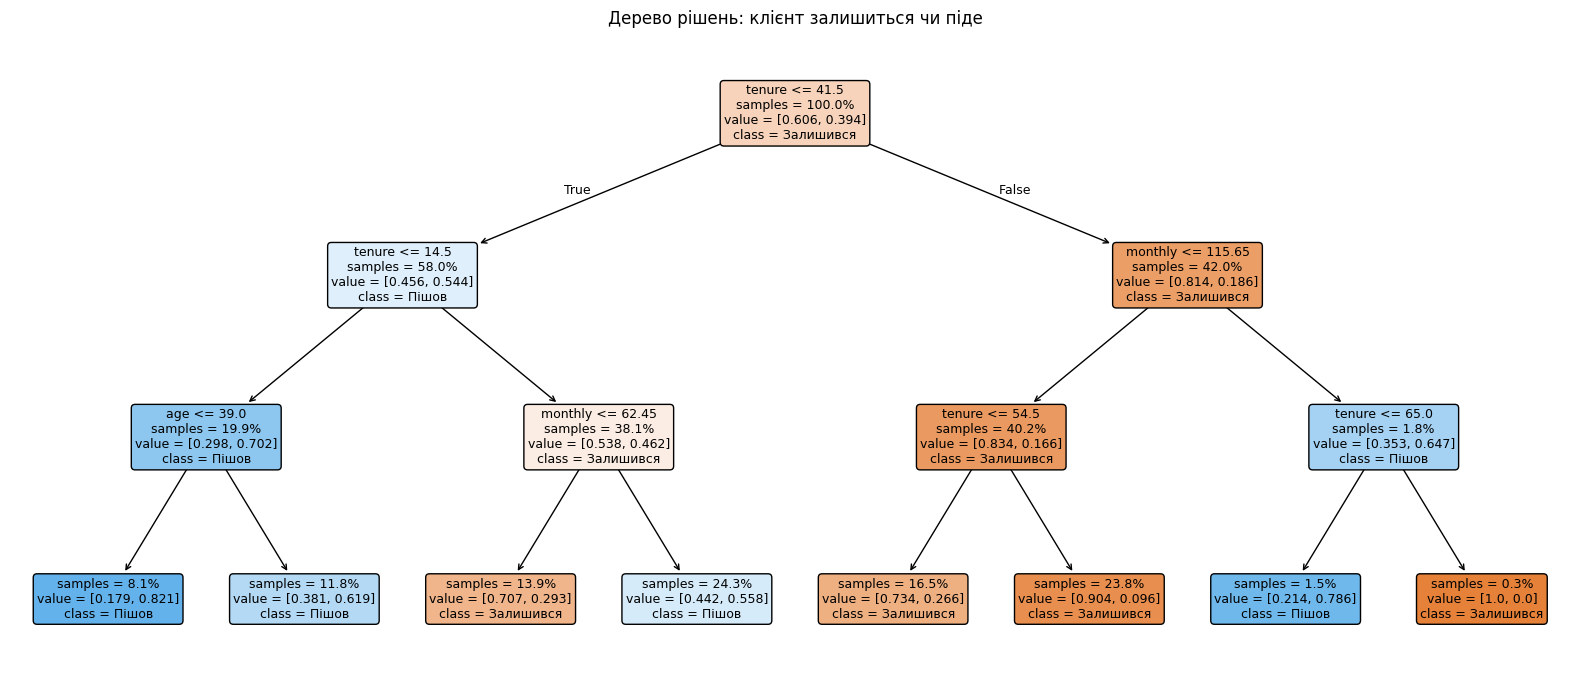

In [8]:
# Імпорт функції для візуалізації дерева
from sklearn.tree import plot_tree

# Розмір області графіка
plt.figure(figsize=(16, 7))

# Візуалізація дерева рішень
plot_tree(

    # Навчена модель
    model_tree,

    # Назви ознак
    feature_names=X.columns,

    # Назви класів
    class_names=['Залишився', 'Пішов'],

    # Зафарбування вузлів кольором
    filled=True,

    # Закруглені блоки
    rounded=True,

    # Розмір тексту
    fontsize=9,

    # Показ часток класів
    proportion=True,
    impurity=False # НЕ показувати impurity (нечистоту вузла)
                # impurity показує, наскільки змішані класи у вузлі
                # наприклад:
                # impurity = 0 → у вузлі лише один клас
                # impurity > 0 → класи змішані
                #
                # якщо поставити True:
                # на схемі будуть показуватись Gini або Entropy
                # це технічний показник якості розбиття
)

# Заголовок графіка
plt.title("Дерево рішень: клієнт залишиться чи піде")

# Автоматичне вирівнювання
plt.tight_layout()

# Відображення графіка
plt.show()

## Як читати дерево рішень

Кожен блок дерева містить:
- умову поділу,
- кількість об'єктів,
- співвідношення класів,
- прогнозований клас.

Наприклад:

```python
tenure <= 12.5
```

означає:
- якщо клієнт користується сервісом менше 12.5 місяців,
- модель переходить в одну гілку,
- інакше — в іншу.

---

Чим вище вузол дерева:
- тим важливіша ознака для моделі.

Decision Tree автоматично шукає:
- найкращі умови,
- які максимально розділяють класи.

## Оцінка якості моделі класифікації

Після того як модель зробила прогноз `y_pred`, потрібно порівняти його з реальними значеннями `y_test`.

Для цього використаємо основні метрики класифікації:
- `accuracy_score` — загальна частка правильних прогнозів;
- `confusion_matrix` — матриця помилок, яка показує, де модель вгадала, а де помилилася;
- `classification_report` — детальний звіт з precision, recall та f1-score.

Accuracy = 59.17% означає, що модель правильно класифікувала приблизно 59% клієнтів із тестової вибірки.

In [9]:
# Імпорт метрик для оцінки якості класифікаційної моделі
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# accuracy_score порівнює реальні значення y_test з прогнозами y_pred
# Результат показує частку правильних відповідей моделі
# Наприклад, 0.59 = 59% правильних прогнозів
acc = accuracy_score(y_test, y_pred)

# Виводимо accuracy у форматі відсотків
print(f"Accuracy = {acc:.2%}\n")

# confusion_matrix показує, скільки разів модель:
# - правильно передбачила, що клієнт залишився
# - правильно передбачила, що клієнт пішов
# - помилково передбачила churn
# - помилково не помітила churn
cm = confusion_matrix(y_test, y_pred)

# Перетворюємо матрицю помилок у DataFrame,
# щоб її було легше читати в notebook
df_cm = pd.DataFrame(
    cm,
    index=[
        "Насправді залишився",
        "Насправді пішов"
    ],
    columns=[
        "Передбачено залишився",
        "Передбачено пішов"
    ]
)

# Виводимо матрицю плутанини
print("Матриця плутанини:")
display(df_cm)

# classification_report дає детальні метрики:
# precision — наскільки точні позитивні прогнози моделі
# recall — скільки реальних випадків класу модель знайшла
# f1-score — баланс між precision і recall
# support — кількість об'єктів кожного класу
print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Залишився", "Пішов"]
))

Accuracy = 59.17%

Матриця плутанини:


,Передбачено залишився,Передбачено пішов
Насправді залишився,85,61
Насправді пішов,37,57



Classification report:
              precision    recall  f1-score   support

   Залишився       0.70      0.58      0.63       146
       Пішов       0.48      0.61      0.54        94

    accuracy                           0.59       240
   macro avg       0.59      0.59      0.59       240
weighted avg       0.61      0.59      0.60       240



## Оцінка якості моделі

Модель Decision Tree показала accuracy 59.17%, тобто правильно класифікувала приблизно 59% клієнтів.

### Матриця плутанини

- 85 клієнтів модель правильно визначила як тих, що залишаться;
- 57 клієнтів модель правильно визначила як тих, що підуть;
- 61 клієнта модель помилково вважала такими, що підуть;
- 37 клієнтів модель не змогла розпізнати як churn.

### Основні метрики

- **Precision** — наскільки можна довіряти прогнозу моделі;
- **Recall** — скільки реальних випадків модель змогла знайти;
- **F1-score** — баланс між precision та recall.

Для класу "Пішли":
- precision = 0.48 — модель часто помиляється при прогнозі churn;
- recall = 0.61 — модель знаходить 61% клієнтів, які реально пішли.

Отже, модель поки що краще визначає клієнтів, які залишаться, ніж тих, які підуть.

## Висновок

Модель Decision Tree показала accuracy приблизно 59.17%.

Це означає, що модель правильно передбачила клас клієнта приблизно у 59 випадках зі 100.

Результат не є дуже високим, тому модель можна покращувати:
- змінити параметр `max_depth`;
- додати або змінити ознаки;
- перевірити баланс класів;
- протестувати інші моделі класифікації.

Матриця плутанини допомагає зрозуміти не тільки загальну точність, але й типи помилок моделі.

# Random Forest

Random Forest — це покращена версія Decision Tree.

Замість одного дерева модель створює багато дерев рішень (`n_estimators=200`) та об'єднує їх прогнози.

Кожне дерево:
- бачить випадкову частину даних;
- будує власні правила;
- голосує за результат.

Потім Random Forest:
- збирає голоси всіх дерев;
- обирає найпопулярніший клас.

Це допомагає:
- зменшити перенавчання;
- підвищити стабільність;
- покращити accuracy.

У нашому випадку:
- одне дерево дало accuracy ≈ 59%;
- Random Forest підвищив accuracy до ≈ 64.6%.

Отже, ансамбль із багатьох дерев працює краще, ніж одне окреме дерево рішень.

In [10]:
# Імпорт Random Forest класифікатора
from sklearn.ensemble import RandomForestClassifier

# Створення моделі Random Forest
model_forest = RandomForestClassifier(

    # Кількість дерев у лісі
    # Чим більше дерев — тим стабільніший прогноз,
    # але модель працює довше
    n_estimators=200,

    # Максимальна глибина кожного дерева
    # Обмеження глибини допомагає зменшити overfitting
    max_depth=6,

    # Фіксація випадковості для однакових результатів
    random_state=RANDOM_STATE
)

# Навчання Random Forest на train data
model_forest.fit(X_train, y_train)

# Прогноз для test data
y_pred_rf = model_forest.predict(X_test)

# Порівняння accuracy:
# y_pred     -> прогноз одного дерева
# y_pred_rf  -> прогноз Random Forest
print(f"Одне дерево: accuracy = {accuracy_score(y_test, y_pred):.2%}")
print(f"Цілий ліс: accuracy = {accuracy_score(y_test, y_pred_rf):.2%}")

Одне дерево: accuracy = 59.17%
Цілий ліс: accuracy = 64.58%


## Висновок

Random Forest показав кращий результат, ніж одне дерево рішень.

Причина:
- модель використовує багато дерев;
- кожне дерево робить власний прогноз;
- фінальне рішення приймається голосуванням.

Такий підхід:
- зменшує випадкові помилки;
- покращує узагальнення;
- робить модель більш стабільною.

## Аналіз важливості ознак (Feature Importance)

Random Forest дозволяє оцінити:
- які ознаки найбільше впливають на прогноз моделі;
- які фактори найважливіші для визначення churn.

Модель автоматично рахує importance для кожної ознаки:
- чим більше значення,
- тим сильніше ознака впливає на рішення моделі.

Графік допомагає швидко побачити:
- які характеристики клієнтів найбільш важливі;
- що найбільше впливає на відтік.

,features,importances
2,support,0.103
3,age,0.135
1,monthly,0.249
0,tenure,0.513


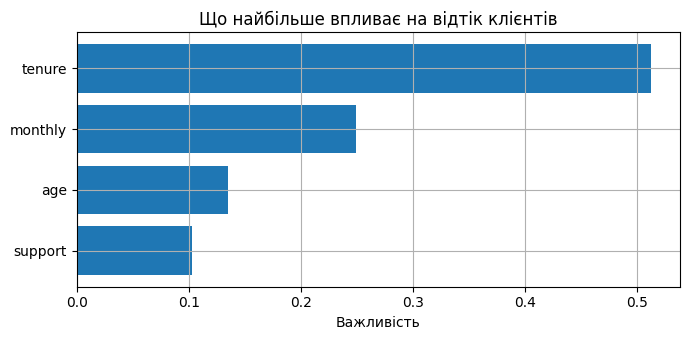

In [11]:
# Створюємо DataFrame з важливістю ознак

# X.columns -> назви ознак
# feature_importances_ -> важливість кожної ознаки,
# яку порахував Random Forest
importances = pd.DataFrame({

        "features": X.columns, # Назви ознак

    # Важливість ознак
    # round(3) округлює значення до 3 знаків
    "importances": model_forest.feature_importances_.round(3)

})

# Сортуємо ознаки:
# ascending=False -> від найбільш важливих до найменш важливих
importances = importances.sort_values(
    "importances",
    ascending=True
)

# Виводимо таблицю importance
display(importances)

# Розмір графіка
plt.figure(figsize=(7, 3.5))

# Горизонтальний bar chart
# features -> по осі Y
# importances -> по осі X
plt.barh(
    importances["features"],
    importances["importances"]
)

# Назва осі X
plt.xlabel("Важливість")

# Заголовок графіка
plt.title("Що найбільше впливає на відтік клієнтів")

# Сітка для зручності читання
plt.grid(True)

# Автоматичне вирівнювання елементів
plt.tight_layout()

# Відображення графіка
plt.show()

## Висновок

Feature Importance показує, які ознаки найбільше впливають на прогноз churn.

Ознаки з найбільшим importance:
- сильніше впливають на рішення моделі;
- частіше використовуються деревами рішень;
- є важливішими для прогнозування відтоку.

Такий аналіз допомагає:
- краще зрозуміти поведінку клієнтів;
- знаходити ключові фактори churn;
- приймати бізнес-рішення на основі даних.

# Прогнозування


## Пояснення

У цьому блоці створюється новий клієнт для прогнозування churn.

Модель отримує:
- тривалість користування сервісом;
- щомісячний платіж;
- кількість звернень у підтримку;
- вік клієнта.

### Навіщо DataFrame

Scikit-learn очікує дані у такому самому форматі, як під час навчання:
- ті самі колонки;
- той самий порядок ознак.

Тому новий клієнт створюється через `pd.DataFrame()`.

### Аналіз клієнта

Цей клієнт:
- користується сервісом лише 3 місяці;
- має багато звернень у підтримку;
- платить досить багато.

Такі ознаки можуть підвищувати ризик churn.

In [12]:
# Створюємо нового клієнта для прогнозу
# DataFrame потрібен, тому що модель очікує таблицю з такими ж колонками, як X

new_client = pd.DataFrame([{

    # Скільки місяців клієнт користується сервісом
    'tenure': 3,

    # Щомісячна оплата
    'monthly': 95,

    # Кількість звернень у підтримку
    'support': 5,

    # Вік клієнта
    'age': 25

}])

# Виводимо нового клієнта
display(new_client)

# Перевірка порядку колонок
# Важливо:
# порядок ознак має бути таким самим, як під час навчання моделі
print(X.columns)

,tenure,monthly,support,age
0,3,95,5,25


Index(['tenure', 'monthly', 'support', 'age'], dtype='object')


## Пояснення результату прогнозування

Модель Random Forest оцінила:
- ймовірність відтоку клієнта = 88.66%.

Тому фінальне рішення моделі:
- клієнт, ймовірно, піде із сервісу.

### Чому модель так вирішила

У клієнта:
- дуже маленький tenure (лише 3 місяці);
- висока monthly оплата;
- багато звернень у підтримку.

Такі ознаки збільшують ризик churn.

### Що показує accuracy = 64.58%

Це загальна точність моделі на test data.

Модель правильно класифікує приблизно:
- 65 клієнтів зі 100.

Тобто прогноз для нового клієнта:
- не гарантія,
- а ймовірнісна оцінка на основі закономірностей у даних.

In [13]:
# predict_proba() повертає ймовірності для кожного класу
#
# [0] -> перший клієнт у таблиці
# [1] -> ймовірність класу "ПІДЕ" (churn = 1)
#
# Наприклад:
# [0.11, 0.89]
# означає:
# 11% -> залишиться
# 89% -> піде

print(
    f"Ймовірність відтоку: "
    f"{model_forest.predict_proba(new_client)[0, 1]:.2%}"
)

# predict() повертає фінальний клас:
# 0 -> залишиться
# 1 -> піде

print(
    f"Рішення: "
    f"{'ПІДЕ' if model_forest.predict(new_client)[0] == 1 else 'ЗАЛИШИТЬСЯ'}"
)

# Розділювач для красивого виводу
print("\n-------------")

# Загальний accuracy моделі на test data
# Показує, наскільки модель у середньому правильна
print(
    f"Точність моделі (accuracy): "
    f"{accuracy_score(y_test, y_pred_rf):.2%}"
)

Ймовірність відтоку: 88.66%
Рішення: ПІДЕ

-------------
Точність моделі (accuracy): 64.58%


## Порівняння способів запису рішення моделі

У прогнозі модель повертає клас:

- `0` — клієнт залишиться;
- `1` — клієнт піде.

У Python значення `1` сприймається як `True`, а `0` — як `False`.

Тому запис:

```python
if pred_model:

In [14]:
# predict() повертає прогноз класу:
# 0 -> клієнт залишиться
# 1 -> клієнт піде

pred_model = model_forest.predict(new_client)[0]

# pred_model містить:
# або 1
# або 0

print(f"Прогноз моделі = {pred_model}")

# =========================
# Варіант 1
# =========================
# Python автоматично сприймає:
# 1 -> True
# 0 -> False

if pred_model:
    print("Клієнт ПІДЕ")
else:
    print("Клієнт ЗАЛИШИТЬСЯ")


# =========================
# Варіант 2
# =========================
# Явна перевірка значення
# Більш зрозумілий варіант для ML-коду

if pred_model == 1:
    print("Клієнт ПІДЕ")
else:
    print("Клієнт ЗАЛИШИТЬСЯ")


# =========================
# Варіант 3
# =========================
# Скорочений запис через ternary operator

print(
    "Клієнт ПІДЕ"
    if pred_model == 1
    else "Клієнт ЗАЛИШИТЬСЯ"
)

Прогноз моделі = 1
Клієнт ПІДЕ
Клієнт ПІДЕ
Клієнт ПІДЕ
